In [1]:
import pandas as pd
import os


In [2]:
os.getcwd()


"C:\\Users\\hardik's laptop\\Downloads\\mental-health-project"

In [3]:
import os
os.getcwd()


"C:\\Users\\hardik's laptop\\Downloads\\mental-health-project"

In [4]:
os.listdir()


['.ipynb_checkpoints',
 'LD_DA.csv',
 'LD_EL.csv',
 'LD_PF.csv',
 'LD_TS.csv',
 'Meta Labelled data kaggel.rtf',
 'Untitled.ipynb']

In [5]:
df_da = pd.read_csv("LD_DA.csv")
df_el = pd.read_csv("LD_EL.csv")
df_pf = pd.read_csv("LD_PF.csv")
df_ts = pd.read_csv("LD_TS.csv")


In [6]:
df_da["root_cause"] = "DA"   # Depression / Anxiety
df_el["root_cause"] = "EL"   # Emotional Loneliness
df_pf["root_cause"] = "PF"   # Personal / Psychological Factors
df_ts["root_cause"] = "TS"   # Trauma / Stress


In [7]:
df = pd.concat([df_da, df_el, df_pf, df_ts], ignore_index=True)


In [8]:
df.shape


(823, 7)

In [9]:
df["root_cause"].value_counts()


root_cause
DA    223
EL    200
PF    200
TS    200
Name: count, dtype: int64

In [10]:
df.columns


Index(['score', 'selftext', 'subreddit', 'title', 'Label', 'root_cause',
       'CAT 1'],
      dtype='object')

In [11]:
df.head(3)


,score,selftext,subreddit,title,Label,root_cause,CAT 1
0,1.0,Tried to watch this documentary “anxious Ameri...,Anxiety,Do people get over anxiety?,Drug and Alcohol,DA,NaN
1,1.0,"i’m currently laying in bed wide awake, feelin...",Anxiety,does anyone else have this big fear of suddenl...,Drug and Alcohol,DA,NaN
2,2.0,Second time trying weed. First time felt close...,Anxiety,3 hour long panic attack after trying weed,Drug and Alcohol,DA,NaN


In [13]:
df["full_text"] = (
    df["title"].fillna("") + " " + df["selftext"].fillna("")
)


In [14]:
df["full_text"].head(3)


0    Do people get over anxiety? Tried to watch thi...
1    does anyone else have this big fear of suddenl...
2    3 hour long panic attack after trying weed Sec...
Name: full_text, dtype: object

In [16]:
df = df[df["full_text"].str.strip() != ""]
df.shape


(800, 8)

In [17]:
!pip install spacy
!python -m spacy download en_core_web_sm


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [22]:
import re
import spacy

nlp = spacy.load("en_core_web_sm")


In [26]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)         # keep only letters
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    
    doc = nlp(text)
    tokens = [
        token.lemma_ 
        for token in doc 
        if not token.is_stop or token.text in ["not", "no", "never"]
    ]
    
    return " ".join(tokens)


In [27]:
df["clean_text"] = df["full_text"].apply(clean_text)


In [28]:
df[["full_text", "clean_text"]].head(3)


,full_text,clean_text
0,Do people get over anxiety? Tried to watch thi...,people anxiety try watch documentary anxious a...
1,does anyone else have this big fear of suddenl...,big fear suddenly lose control reality m curre...
2,3 hour long panic attack after trying weed Sec...,hour long panic attack try weed second time tr...


In [29]:
df = df[df["clean_text"].str.strip() != ""]
df.shape


(800, 9)

In [30]:
risk_map = {
    "DA": "High",
    "TS": "High",
    "EL": "Moderate",
    "PF": "Moderate"
}


In [31]:
df["risk_level"] = df["root_cause"].map(risk_map)


In [36]:
df[["root_cause", "risk_level"]].head(300)


,root_cause,risk_level
0,DA,High
1,DA,High
2,DA,High
3,DA,High
4,DA,High
...,...,...
318,EL,Moderate
319,EL,Moderate
320,EL,Moderate
321,EL,Moderate


In [37]:
df["risk_level"].value_counts()


risk_level
High        400
Moderate    400
Name: count, dtype: int64

In [72]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=3,               # remove rare words
    max_df=0.9,             # remove overly common words
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [74]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [75]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        High       0.80      0.71      0.75        80
    Moderate       0.74      0.82      0.78        80

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



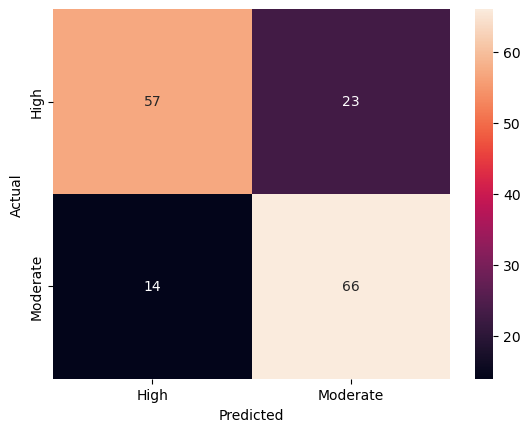

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["High", "Moderate"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["High", "Moderate"],
    yticklabels=["High", "Moderate"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [77]:
import joblib


In [78]:
joblib.dump(model, "risk_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']

In [79]:
import os
os.listdir()


['.ipynb_checkpoints',
 'LD_DA.csv',
 'LD_EL.csv',
 'LD_PF.csv',
 'LD_TS.csv',
 'Meta Labelled data kaggel.rtf',
 'risk_model.pkl',
 'tfidf_vectorizer.pkl',
 'Untitled.ipynb']

In [80]:
loaded_model = joblib.load("risk_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")


In [93]:
sample_text = ["i feel sad and happy at the same time"]

sample_vec = loaded_tfidf.transform(sample_text)
loaded_model.predict(sample_vec)


array(['High'], dtype=object)

In [82]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [83]:
from sklearn.metrics import classification_report

svm_pred = svm_model.predict(X_test_tfidf)

print(classification_report(y_test, svm_pred))


              precision    recall  f1-score   support

        High       0.72      0.70      0.71        80
    Moderate       0.71      0.72      0.72        80

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160



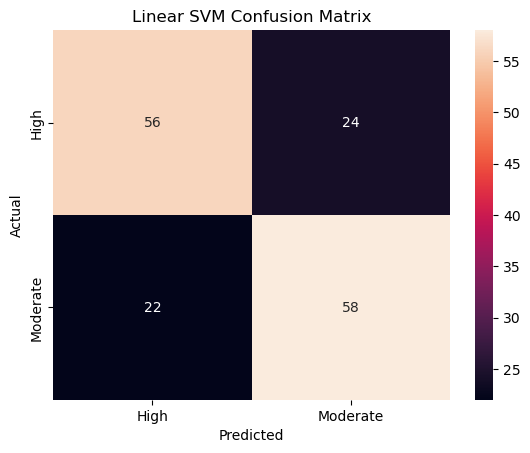

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, svm_pred, labels=["High", "Moderate"])

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["High", "Moderate"],
    yticklabels=["High", "Moderate"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM Confusion Matrix")
plt.show()


In [85]:
y_proba = model.predict_proba(X_test_tfidf)


In [86]:
model.classes_


array(['High', 'Moderate'], dtype=object)

In [87]:
import numpy as np
from sklearn.metrics import classification_report

thresholds = [0.5, 0.45, 0.4, 0.35]

for t in thresholds:
    y_pred_thresh = np.where(y_proba[:, 0] >= t, "High", "Moderate")
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_thresh))



Threshold = 0.5
              precision    recall  f1-score   support

        High       0.80      0.71      0.75        80
    Moderate       0.74      0.82      0.78        80

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160


Threshold = 0.45
              precision    recall  f1-score   support

        High       0.65      0.88      0.74        80
    Moderate       0.81      0.53      0.64        80

    accuracy                           0.70       160
   macro avg       0.73      0.70      0.69       160
weighted avg       0.73      0.70      0.69       160


Threshold = 0.4
              precision    recall  f1-score   support

        High       0.56      0.94      0.70        80
    Moderate       0.81      0.28      0.41        80

    accuracy                           0.61       160
   macro avg       0.69      0.61      0.56       160
weighted avg       0.6

In [88]:
y_proba = model.predict_proba(X_test_tfidf)

thresholds = [0.5, 0.45, 0.4]

for t in thresholds:
    y_pred_thresh = np.where(y_proba[:, 0] >= t, "High", "Moderate")
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_thresh))



Threshold = 0.5
              precision    recall  f1-score   support

        High       0.80      0.71      0.75        80
    Moderate       0.74      0.82      0.78        80

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160


Threshold = 0.45
              precision    recall  f1-score   support

        High       0.65      0.88      0.74        80
    Moderate       0.81      0.53      0.64        80

    accuracy                           0.70       160
   macro avg       0.73      0.70      0.69       160
weighted avg       0.73      0.70      0.69       160


Threshold = 0.4
              precision    recall  f1-score   support

        High       0.56      0.94      0.70        80
    Moderate       0.81      0.28      0.41        80

    accuracy                           0.61       160
   macro avg       0.69      0.61      0.56       160
weighted avg       0.6

In [89]:
final_threshold = 0.45
y_pred_final = np.where(y_proba[:, 0] >= final_threshold, "High", "Moderate")


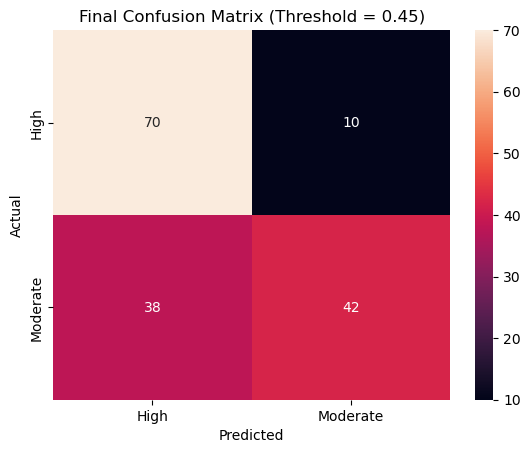

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final, labels=["High", "Moderate"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["High", "Moderate"],
    yticklabels=["High", "Moderate"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix (Threshold = 0.45)")
plt.show()


In [91]:
import joblib

joblib.dump(model, "mental_health_risk_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save threshold as metadata
joblib.dump({"threshold": 0.45}, "model_config.pkl")


['model_config.pkl']